In [ ]:
# Given a saved dataframe with all seeds and their corresponding policies, recover the latents

In [36]:
from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
torch.cuda.empty_cache()
pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "stabilityai/sdxl-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerAncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [197]:
def get_latent_list_from_seeds(seeds: list[int]) -> list[Latent]:
    generators = [torch.Generator(device="cpu").manual_seed(seed) for seed in seeds]
    latents = [
            pipe.prepare_latents(
                batch_size=1,
                num_channels_latents=pipe.unet.config.in_channels,
                height=512,
                width=512,
                dtype=pipe.unet.dtype,
                device="cpu",
                generator=generator,
            )[0] / pipe.scheduler.init_noise_sigma
            for generator in generators
        ]
    return latents

In [198]:
# As an example, load in latent_alpha=0.75_10x10
import pandas as pd
example_df = pd.read_csv("results/latent_alpha=0.75_10x10/metrics.csv")
example_df["alpha"] = 0.75

In [199]:
# Each datapoint for a round is one winner image, and three/two non-winner images
from typing import NamedTuple
import torch

Latent = torch.Tensor # we'll represent as 3-dimensional, not 4-dimensional. We'll add the first dimension (batch size) only when needed.

class DataPoint(NamedTuple):
    round: int
    trial_id: str
    prompt_id: str
    alpha: float
    winner_latent: Latent
    loser_latents: list[Latent]

In [ ]:
def get_data_point(df: pd.DataFrame, round: int, trial_id: str, prompt_id: str, alpha: float) -> tuple[DataPoint, DataPoint]:
    """
    Given a dataframe with all seeds and their corresponding policies,
    round: must be 0-4
    trial_id: str in "trial0" to "trial9"
    prompt_id: str
    alpha: float
    """
    # first, gather the sixteen rows corresponding to this round, trial, and prompt
    trial_rows = df[(df["trial_id"] == trial_id) & (df["prompt_id"] == prompt_id) & (df["alpha"] == alpha)]

    print("trial_rows", trial_rows)

    this_round_rows = trial_rows[trial_rows["round"] == round]

    if round == 0:
        # get this round's winner latent and non-winner seed latents BEFORE adaptation
        this_round_winner_latent_seed = this_round_rows[this_round_rows["chosen"] == True]["seed"].item()
        this_round_loser_latents_seeds = this_round_rows[this_round_rows["chosen"] == False]["seed"].tolist()

        this_round_winner_latent = get_latent_list_from_seeds([this_round_winner_latent_seed])[0]
        this_round_loser_latents = get_latent_list_from_seeds(this_round_loser_latents_seeds)
    
        return DataPoint(round, trial_id, prompt_id, alpha, this_round_winner_latent, this_round_loser_latents)
    
    # Otherwise, we need to reconstruct the chosen latent of the previous round (the one survived to this round)
    round_0_winner_seed = trial_rows[(trial_rows["round"] == 0) & (trial_rows["chosen"] == True)]["seed"].item()
    round_0_winner_latent = get_latent_list_from_seeds([round_0_winner_seed])[0]
    
    previous_round_winner_latent = round_0_winner_latent

    scale_factor = ((1 - alpha)**2 + alpha**2)**0.5
    for i in range(1, round):
        previous_row_winner_row = trial_rows[(trial_rows["round"] == i) & (trial_rows["chosen"] == True)]

        # if the winner was reused from the previous round, don't update
        if previous_row_winner_row["reused_from_previous"].item():
            pass
        # otherwise, update by applying the seed and mixing
        else:
            previous_round_noise_seed = previous_row_winner_row["seed"].item()
            previous_round_noise_latent = get_latent_list_from_seeds([previous_round_noise_seed])[0]
            previous_round_winner_latent = alpha * previous_round_noise_latent + (1 - alpha) * previous_round_winner_latent
            previous_round_winner_latent /= scale_factor

    # now we will have recovered the winner from the previous round
    this_round_latents: list = [None for _ in range(4)]
    this_round_latents[0] = previous_round_winner_latent

    for i in range(1, 4):
        non_king_latent_seed = this_round_rows[(this_round_rows["reused_from_previous"] == False) & (this_round_rows["image_idx"] == i)]["seed"].item()
        print("non_king_latent_seed", non_king_latent_seed)
        latent = alpha * get_latent_list_from_seeds([non_king_latent_seed])[0] + (1 - alpha) * previous_round_winner_latent
        latent /= scale_factor
        this_round_latents[i] = latent

    # now that we have these, assign to winner and loser
    winner_idx = this_round_rows[this_round_rows["chosen"] == True]["image_idx"].item()
    
    this_round_winner_latent = None
    this_round_loser_latents = []
    for i in range(0, 4):
        if i == winner_idx:
            this_round_winner_latent = this_round_latents[i]
        else:
            this_round_loser_latents.append(this_round_latents[i])

    return DataPoint(round, trial_id, prompt_id, alpha, this_round_winner_latent, this_round_loser_latents)

In [ ]:
"""
prompt_id,trial_id,round,image_idx,image_path,user_score,chosen,prompt,seed,mean_pixel,reused_from_previous
009606-0136,trial0,0,0,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round0/image0.png,1.0473462343215942,True,logo for a coffee chain,11396,0.43792152404785156,False
009606-0136,trial0,0,1,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round0/image1.png,-0.5392330884933472,False,logo for a coffee chain,77398,0.7618764042854309,False
009606-0136,trial0,0,2,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round0/image2.png,-0.1260194629430771,False,logo for a coffee chain,55303,0.5034304261207581,False
009606-0136,trial0,0,3,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round0/image3.png,1.003163456916809,False,logo for a coffee chain,4166,0.45758748054504395,False

009606-0136,trial0,1,0,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round1/image0.png,1.0473462343215942,False,logo for a coffee chain,11396,0.43792152404785156,True
009606-0136,trial0,1,1,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round1/image1.png,0.5898248553276062,False,logo for a coffee chain,3906,0.4530443847179413,False
009606-0136,trial0,1,2,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round1/image2.png,1.1401515007019043,True,logo for a coffee chain,12281,0.5231702923774719,False
009606-0136,trial0,1,3,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round1/image3.png,-0.3460875153541565,False,logo for a coffee chain,28658,0.5631957054138184,False

009606-0136,trial0,2,0,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round2/image0.png,1.1401515007019043,True,logo for a coffee chain,12281,0.5231702923774719,True
009606-0136,trial0,2,1,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round2/image1.png,1.1303033828735352,False,logo for a coffee chain,30496,0.46017536520957947,False
009606-0136,trial0,2,2,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round2/image2.png,0.2749439477920532,False,logo for a coffee chain,66238,0.6083332896232605,False
009606-0136,trial0,2,3,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round2/image3.png,0.8969414234161377,False,logo for a coffee chain,78908,0.5108384490013123,False
009606-0136,trial0,3,0,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round3/image0.png,1.1401515007019043,True,logo for a coffee chain,12281,0.5231702923774719,True
009606-0136,trial0,3,1,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round3/image1.png,0.9545550346374512,False,logo for a coffee chain,3479,0.45535197854042053,False
009606-0136,trial0,3,2,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round3/image2.png,0.8592708110809326,False,logo for a coffee chain,73564,0.519206702709198,False
009606-0136,trial0,3,3,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round3/image3.png,-0.4301868975162506,False,logo for a coffee chain,26063,0.6521996855735779,False
"""

In [213]:
example_round = 1
example_trial_id = "trial0"
example_prompt_id="009606-0136"
example_alpha = 0.75

example_data_point = get_data_point(example_df, round=example_round, trial_id=example_trial_id, prompt_id=example_prompt_id, alpha=example_alpha)

# Get the prompt from the prompt id
example_prompt: str = example_df[example_df["prompt_id"] == example_prompt_id]["prompt"].unique().item()

trial_rows       prompt_id trial_id  round  image_idx  \
16  009606-0136   trial0      0          0   
17  009606-0136   trial0      0          1   
18  009606-0136   trial0      0          2   
19  009606-0136   trial0      0          3   
20  009606-0136   trial0      1          0   
21  009606-0136   trial0      1          1   
22  009606-0136   trial0      1          2   
23  009606-0136   trial0      1          3   
24  009606-0136   trial0      2          0   
25  009606-0136   trial0      2          1   
26  009606-0136   trial0      2          2   
27  009606-0136   trial0      2          3   
28  009606-0136   trial0      3          0   
29  009606-0136   trial0      3          1   
30  009606-0136   trial0      3          2   
31  009606-0136   trial0      3          3   

                                           image_path  user_score  chosen  \
16  outputs/2025-12-03_23-57-00/images/009606-0136...    1.047346    True   
17  outputs/2025-12-03_23-57-00/images/009606-0136..

  0%|          | 0/1 [00:00<?, ?it/s]

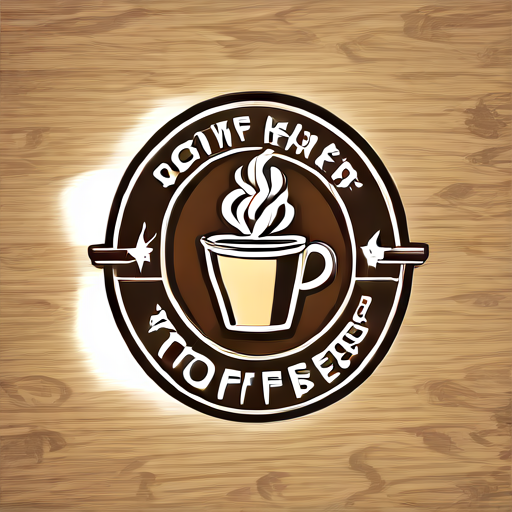

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

loser images:


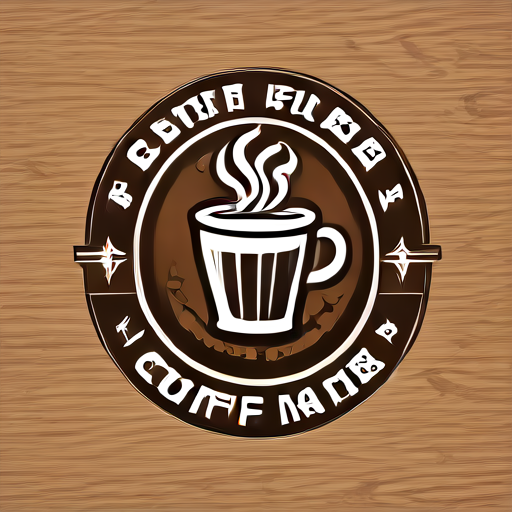

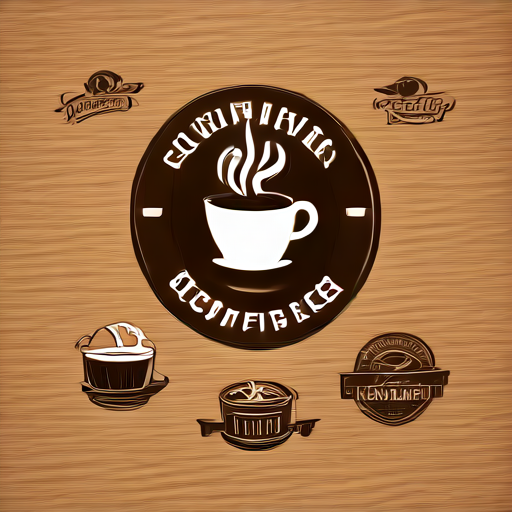

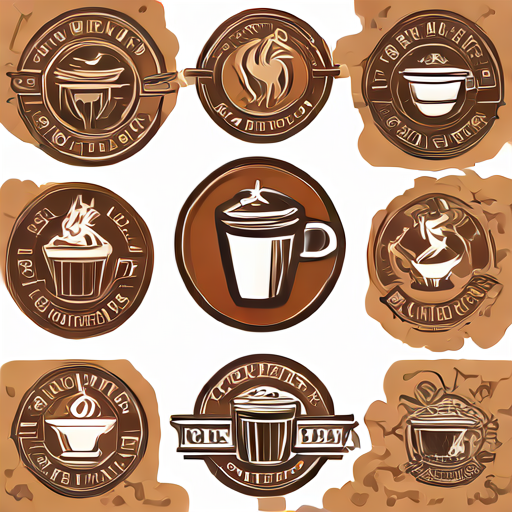

In [214]:
winner_image = pipe(
    prompt=example_prompt,
    num_images_per_prompt=1,
    latents=example_data_point.winner_latent.unsqueeze(0),
    width=512,
    height=512,
    num_inference_steps=1,
    guidance_scale=0.0,
).images[0]

# display
display(winner_image)

loser_images = [
    pipe(
        prompt=example_prompt,
        num_images_per_prompt=1,
        latents=loser_latent.unsqueeze(0),
        width=512,
        height=512,
        num_inference_steps=1,
        guidance_scale=0.0,
    ).images[0]
    for loser_latent in example_data_point.loser_latents
]

# display
print("loser images:")
for loser_image in loser_images:
    display(loser_image)


In [ ]:
# display the actual based on the example
example_rows = example_df[(example_df["round"] == example_round) & (example_df["trial_id"] == example_trial_id) & (example_df["prompt_id"] == example_prompt_id) & (example_df["alpha"] == example_alpha)]
winner_row = example_rows[example_rows["chosen"] == True]
loser_rows = example_rows[example_rows["chosen"] == False]

In [ ]:
loser_rows

,prompt_id,trial_id,round,image_idx,image_path,user_score,chosen,prompt,seed,mean_pixel,reused_from_previous,alpha
1585,005695-0057,trial9,0,1,outputs/2025-12-03_04-14-38/images/005695-0057...,0.900294,False,"a concept art of a vehicle, cyberpunk",44376,0.353177,False,0.25
1586,005695-0057,trial9,0,2,outputs/2025-12-03_04-14-38/images/005695-0057...,1.061767,False,"a concept art of a vehicle, cyberpunk",81692,0.358715,False,0.25
1587,005695-0057,trial9,0,3,outputs/2025-12-03_04-14-38/images/005695-0057...,1.035664,False,"a concept art of a vehicle, cyberpunk",90795,0.345814,False,0.25


In [ ]:
import PIL
from pathlib import Path
start_path = Path(f"results/latent_alpha={example_alpha}_10x10")

old_actual_winner_image_path: Path = Path(winner_row["image_path"].item())
# replace the first two parts of the path with start path
actual_winner_image_path: Path = start_path / Path(*old_actual_winner_image_path.parts[2:])

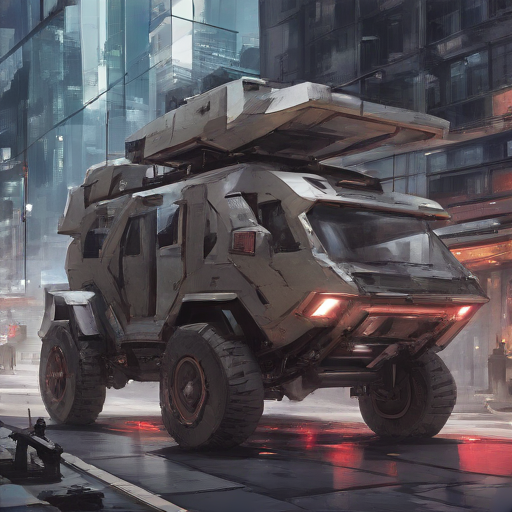

In [ ]:
# Load the image
actual_winner_image = PIL.Image.open(actual_winner_image_path)
display(actual_winner_image)

In [ ]:
# here's our design

